## Summarize the time series
The ejection fraction is the proportion of blood squeezed out of the left ventricle each heartbeat. To calculate it, radiologists have to identify the maximum volume (systolic volume) and the minimum volume (diastolic volume) of the ventricle.

For this exercise, create a time series of volume calculations. There are 20 time points in both vol_ts and labels. The data is ordered by (time, plane, row, col).

- Initialize an empty array with 20 elements using np.zeros().
- Calculate the volume of each image voxel. (Consult the meta dictionary for sampling rates.)
- For each time point, count the pixels in labels, and update the time series array.
- Plot the time series using plt.plot().

In [ ]:
# Create an empty time series
ts = np.zeros(20)

# Calculate volume at each voxel
d0, d1, d2, d3 = vol_ts.meta['sampling']
dvoxel = d1 * d2 * d3

# Loop over the labeled arrays
for t in range(20):
    nvoxels = ndi.sum(1, labels[t], index=1)
    ts[t] = dvoxel * nvoxels

# Plot the data
plt.plot(ts)
format_and_render_plot()

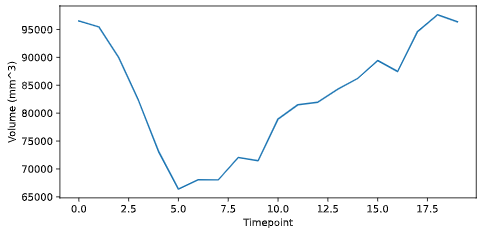

## Measure ejection fraction
The ejection fraction is defined as:

 

…where 
 is left ventricle volume for one 3D timepoint.

To close our investigation, plot slices from the maximum and minimum volumes by analyzing the volume time series (ts). Then, calculate the ejection fraction.

- Get the index of the minimum and maximum volume images using np.argmin() and np.argmax().
- Plot the extreme volumes together. Display the images along the fifth plane, e.g. (vol_ts[t, 4]).



In [ ]:
# Get index of max and min volumes
tmax = np.argmax(ts)
tmin = np.argmin(ts)

# Plot the largest and smallest volumes
fig, axes = plt.subplots(2,1)
axes[0].imshow(vol_ts[tmax, 4], vmax=160)
axes[1].imshow(vol_ts[tmin, 4], vmax=160)
format_and_render_plots()

Calculate the ejection volume and fraction using the min() and max() methods of ts. Print these values.

In [ ]:
# Calculate ejection fraction
ej_vol = ts.max() - ts.min()
ej_frac = ej_vol / ts.max()
print('Est. ejection volume (mm^3):', ej_vol)
print('Est. ejection fraction:', ej_frac)
Est. ejection volume (mm^3): 31268.00536236538
Est. ejection fraction: 0.3202054794520548